In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import joblib
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Load and preprocess the data
df = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='7')
df.dropna(inplace=True)

# Define features
features = ['PC', 'PC_TYPE', 'FA','FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
            'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%']

X = df[features].values
Y = df['fc (MPa)'].values  # Ensure this column exists in your DataFrame

# Normalize the data
x_mean = X.mean(0)
x_std = X.std(0)
X_normal = (X - x_mean) / x_std

y_mean = Y.mean()
y_std = Y.std()
Y_normal = (Y - y_mean) / y_std

Xtrain, Xtest, ytrain, ytest = train_test_split(X_normal, Y_normal, train_size=0.85, random_state=42)


In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Load and preprocess the data
df = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='7')
df.dropna(inplace=True)

# Define features
features = ['PC', 'PC_TYPE', 'FA','FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
            'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%']

X = df[features].values
Y = df['fc (MPa)'].values  # Ensure this column exists in your DataFrame

# Normalize the data
x_mean = X.mean(0)
x_std = X.std(0)
X_normal = (X - x_mean) / x_std

y_mean = Y.mean()
y_std = Y.std()
Y_normal = (Y - y_mean) / y_std

Xtrain, Xtest, ytrain, ytest = train_test_split(X_normal, Y_normal, train_size=0.85, random_state=42)
# Set Random Forest hyperparameters
n_estimators = 500  # Number of trees
max_depth = 20  # Maximum depth of the trees

# Create the Random Forest model
random_forest_model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=42, bootstrap=True)

# Train the model using the residual values as the target
random_forest_model.fit(Xtrain, ytrain)

# Create a new DataFrame for the partial dependence plot
mean_values = X_normal.mean(axis=0)
fa_percent_range = np.linspace(X_normal[:, features.index('FA%')].min(), X_normal[:, features.index('FA%')].max(), 100)

# Prepare data for predictions (keep pd.DataFrame for pdp_data)
pdp_data = pd.DataFrame(np.tile(mean_values, (fa_percent_range.size, 1)), columns=features)
pdp_data['FA%'] = fa_percent_range  # Vary FA%

# Make predictions
pdp_predictions_normalized = random_forest_model.predict(pdp_data)

# Inverse transformation of predictions to original scale
pdp_predictions_original = pdp_predictions_normalized * y_std + y_mean

# Inverse transformation of FA% to original scale
fa_percent_original = pdp_data['FA%'] * (x_std[features.index('FA%')] if features.index('FA%') < len(x_std) else 1) + (x_mean[features.index('FA%')] if features.index('FA%') < len(x_mean) else 0)

# Save predictions to a DataFrame
pdp_results = pd.DataFrame({'FA% (Original Scale)': fa_percent_original, 'Predicted_fc': pdp_predictions_original})

# Save the predictions to a CSV file
pdp_results.to_csv('pdp_RF_7.csv', index=False)

X has feature names, but RandomForestRegressor was fitted without feature names


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split

# Define the ANN model
class ANNModel(nn.Module):
    def __init__(self, input_dim, layers, neurons):
        super(ANNModel, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, neurons))
        self.layers.append(nn.ReLU())
        for _ in range(layers - 1):
            self.layers.append(nn.Linear(neurons, neurons))
            self.layers.append(nn.ReLU())
        self.layers.append(nn.Linear(neurons, 1))

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

# # Load and preprocess the data
# df = pd.read_excel(r'updated_fc_predictions.xlsx', sheet_name='Sheet1')
# df.dropna(inplace=True)

# # Define features
# features = ['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
#             'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']
# X = df[features].values
# Y = df['fc (MPa)'].values  # Ensure this column exists in your DataFrame

# # Normalize the data
# x_mean = X.mean(0)
# x_std = X.std(0)
# X_normal = (X - x_mean) / x_std

# y_mean = Y.mean()
# y_std = Y.std()
# Y_normal = (Y - y_mean) / y_std

# Xtrain, Xtest, ytrain, ytest = train_test_split(X_normal, Y_normal, train_size=0.85, random_state=42)

# Set ANN hyperparameters
layers = 2  # Number of layers
neurons = 52  # Number of neurons per layer
learning_rate = 0.00077  # Learning rate

# Create the ANN model
ann_model = ANNModel(input_dim=Xtrain.shape[1], layers=layers, neurons=neurons)
optimizer = optim.Adam(ann_model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

# Training the model
epochs = 300
for epoch in range(epochs):
    ann_model.train()
    optimizer.zero_grad()
    ytrain_tensor = torch.FloatTensor(ytrain).view(-1, 1)  # Ensure ytrain is a column vector
    ytrain_pred = ann_model(torch.FloatTensor(Xtrain))
    loss = criterion(ytrain_pred, ytrain_tensor)
    loss.backward()
    optimizer.step()

# Create a new DataFrame for the partial dependence plot
mean_values = X_normal.mean(axis=0)
fa_percent_range = np.linspace(X_normal[:, features.index('FA%')].min(), X_normal[:, features.index('FA%')].max(), 100)

# Prepare data for predictions
pdp_data = pd.DataFrame(np.tile(mean_values, (fa_percent_range.size, 1)), columns=features)
pdp_data['FA%'] = fa_percent_range  # Vary FA%



# Convert pdp_data to tensor
pdp_data_tensor = torch.FloatTensor(pdp_data.values)

# Make predictions using the ANN model
pdp_predictions_normalized = ann_model(pdp_data_tensor).detach().numpy().flatten()  # Ensure predictions are 1D

# Inverse transformation of predictions to original scale
pdp_predictions_original = pdp_predictions_normalized * y_std + y_mean  # Ensure predictions are 1D

# Inverse transformation of FA% to original scale
fa_percent_original = pdp_data['FA%'] * x_std[features.index('FA%')] + x_mean[features.index('FA%')]

# Ensure fa_percent_original is a 1D array
fa_percent_original = fa_percent_original.values.flatten()  # Flatten to ensure 1D

# Save predictions to a DataFrame
pdp_results = pd.DataFrame({
    'FA% (Original Scale)': fa_percent_original, 
    'Predicted_fc': pdp_predictions_original
})

# Save the predictions to a CSV file
pdp_results.to_csv('pdp_ANN_7.csv', index=False)



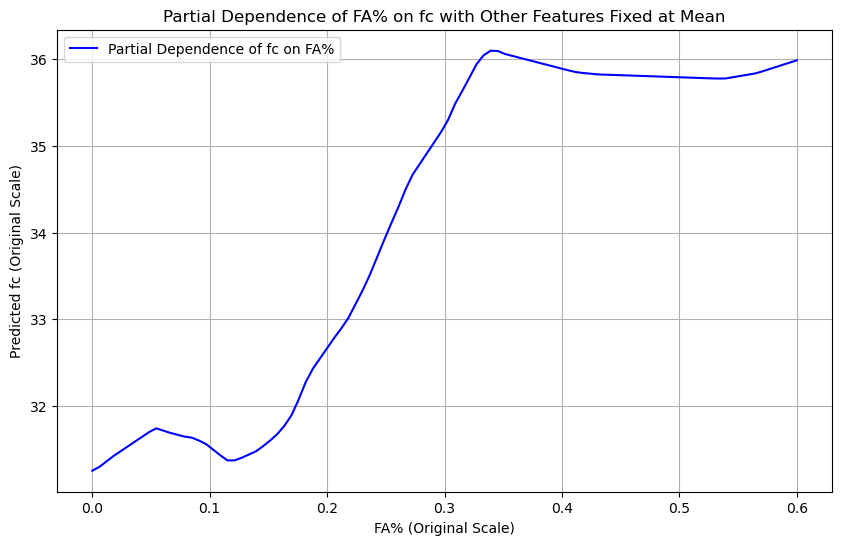

In [24]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(fa_percent_original, pdp_predictions_original, label='Partial Dependence of fc on FA%', color='blue')
plt.title('Partial Dependence of FA% on fc with Other Features Fixed at Mean')
plt.xlabel('FA% (Original Scale)')
plt.ylabel('Predicted fc (Original Scale)')
# plt.axhline(0, color='red', linestyle='--', label='Zero Line')  # Add a zero line for reference
plt.legend()
plt.grid()
plt.show()

In [25]:
class RegressionModel(nn.Module):
    def __init__(self, input_dim, layers, neurons):
        super(RegressionModel, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, neurons))
        self.layers.append(nn.ReLU())
        for _ in range(layers - 1):
            self.layers.append(nn.Linear(neurons, neurons))
            self.layers.append(nn.ReLU())
        self.layers.append(nn.Linear(neurons, 1))

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


def custom_loss(outputs, targets, inputs, a, b, e, d):
    outputs = outputs.squeeze()  # Remove the extra dimension
    mse_loss = nn.MSELoss()(outputs, targets)

    # Use the constant value of AGE (7) as a tensor
    AGE = torch.tensor(7.0).to(outputs.device)  # Ensure it's on the same device as the outputs
    wb = inputs[:, -7]  # Ensure this is still a valid feature index

    # Calculate predicted fc using the constant AGE
    fc_pred = (a * torch.log(AGE) + b) * (e * torch.pow(AGE, d)) ** (-wb)
    
    residual = torch.abs(outputs - fc_pred.unsqueeze(1))
    residual = torch.nan_to_num(residual, nan=0.0, posinf=1e10, neginf=-1e10)
    mean_square_residual = torch.mean(residual ** 2)

    if mean_square_residual.item() > 0:
        residual_normalized = residual * torch.sqrt(mse_loss / mean_square_residual)
    else:
        residual_normalized = residual
    
    total_loss = 0.5 * mse_loss + 0.5 * torch.mean(residual_normalized)
    return total_loss




# Training function
def train_model(model, optimizer, Xtrain, ytrain, epochs=300, batch_size=8, a=None, b=None, e=None, d=None):
    dataset = torch.utils.data.TensorDataset(Xtrain, ytrain)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        model.train()
        for inputs, targets in dataloader:
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()  # Squeeze to match dimensions
            loss = custom_loss(outputs, targets, inputs, a, b, e, d)
            loss.backward()
            optimizer.step()

# Hyperparameters
layers = 2  # Number of layers between 2 and 5
neurons = 52  # Number of neurons per layer
learning_rate = 0.00076  # Fixed learning rate

# Initialize model
model = RegressionModel(Xtrain.shape[1], layers, neurons)

# Move model and data to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
Xtrain_tensor = torch.FloatTensor(Xtrain).to(device)
ytrain_tensor = torch.FloatTensor(ytrain).to(device)
Xtest_tensor = torch.FloatTensor(Xtest).to(device)

# Define custom parameters
a = 40.5
b = 15.3
e = 6.5
d = 0.36

# Train the model
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
train_model(model, optimizer, Xtrain_tensor, ytrain_tensor, a=a, b=b, e=e, d=d)

# Create a new DataFrame for the partial dependence plot
mean_values = X_normal.mean(axis=0)
fa_percent_range = np.linspace(X_normal[:, features.index('FA%')].min(), X_normal[:, features.index('FA%')].max(), 100)

# Prepare data for predictions
pdp_data = pd.DataFrame(np.tile(mean_values, (fa_percent_range.size, 1)), columns=features)
pdp_data['FA%'] = fa_percent_range  # Vary FA%

# Convert pdp_data to tensor
pdp_data_tensor = torch.FloatTensor(pdp_data.values).to(device)

# Make predictions using the ANN model
pdp_predictions_normalized = model(pdp_data_tensor).detach().cpu().numpy()  # Use forward pass and detach

# Inverse transformation of predictions to original scale
pdp_predictions_original = pdp_predictions_normalized.flatten() * y_std + y_mean  # Ensure predictions are 1D

# Inverse transformation of FA% to original scale
fa_percent_original = pdp_data['FA%'] * x_std[features.index('FA%')] + x_mean[features.index('FA%')]
fa_percent_original = fa_percent_original.values.flatten()  # Ensure it's 1D

# Save predictions to a DataFrame
pdp_results = pd.DataFrame({'FA% (Original Scale)': fa_percent_original, 'Predicted_fc': pdp_predictions_original})

# Save the predictions to a CSV file
pdp_results.to_csv('pdp_KINN_7.csv', index=False)


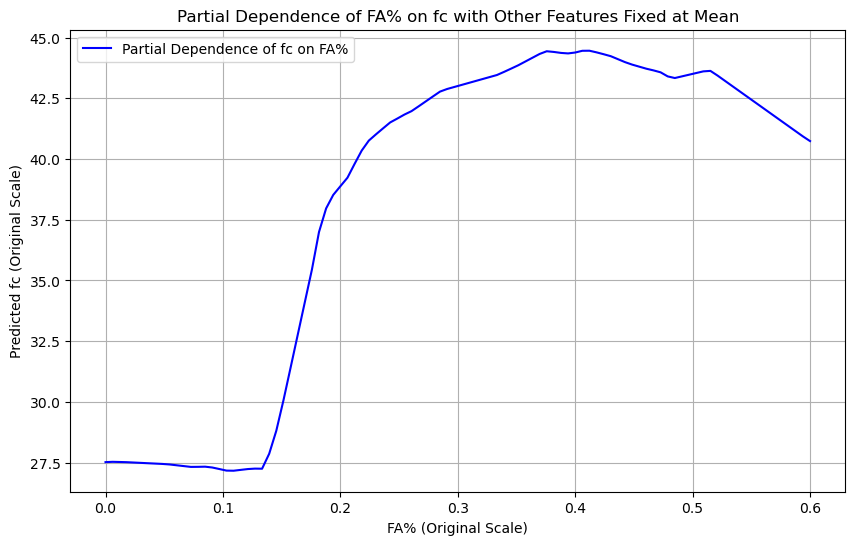

In [26]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(fa_percent_original, pdp_predictions_original, label='Partial Dependence of fc on FA%', color='blue')
plt.title('Partial Dependence of FA% on fc with Other Features Fixed at Mean')
plt.xlabel('FA% (Original Scale)')
plt.ylabel('Predicted fc (Original Scale)')
# plt.axhline(0, color='red', linestyle='--', label='Zero Line')  # Add a zero line for reference
plt.legend()
plt.grid()
plt.show()


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Load and preprocess the data
df = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='7')
df.dropna(inplace=True)

# Define features
features = ['PC', 'PC_TYPE', 'FA', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
            'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%']

X = df[features].values
Y = df['fc (MPa)'].values  # Ensure this column exists in your DataFrame

# Normalize the data
x_mean = X.mean(0)
x_std = X.std(0)
X_normal = (X - x_mean) / x_std

y_mean = Y.mean()
y_std = Y.std()
Y_normal = (Y - y_mean) / y_std

Xtrain, Xtest, ytrain, ytest = train_test_split(X_normal, Y_normal, train_size=0.85, random_state=42)

# Set hyperparameters for XGBoost
params = {
    'subsample': 0.7,
    'reg_lambda': 0.1,
    'reg_alpha': 0.01,
    'n_estimators': 200,
    'max_depth': 7,
    'learning_rate': 0.1,
    'colsample_bytree': 0.9,
}

# Train the XGBoost model
xgboost_model = xgb.XGBRegressor(**params)
xgboost_model.fit(Xtrain, ytrain)

# Create a new DataFrame for the partial dependence plot
mean_values = X_normal.mean(axis=0)
fa_percent_range = np.linspace(X_normal[:, features.index('FA%')].min(), X_normal[:, features.index('FA%')].max(), 100)

# Prepare data for predictions
pdp_data = pd.DataFrame(np.tile(mean_values, (fa_percent_range.size, 1)), columns=features)
pdp_data['FA%'] = fa_percent_range  # Vary FA%

# Convert pdp_data to tensor
pdp_data_tensor = torch.FloatTensor(pdp_data.values).to(device)

pdp_predictions = xgboost_model.predict(pdp_data)
# # Make predictions using the ANN model
# pdp_predictions_normalized = xgboost_model(pdp_data_tensor).detach().cpu().numpy()  # Use forward pass and detach

# Inverse transformation of predictions to original scale
pdp_predictions_original = pdp_predictions.flatten() * y_std + y_mean  # Ensure predictions are 1D

# Inverse transformation of FA% to original scale
fa_percent_original = pdp_data['FA%'] * x_std[features.index('FA%')] + x_mean[features.index('FA%')]
fa_percent_original = fa_percent_original.values.flatten()  # Ensure it's 1D

# Save predictions to a DataFrame
pdp_results = pd.DataFrame({'FA% (Original Scale)': fa_percent_original, 'Predicted_fc': pdp_predictions_original})

# Save the predictions to a CSV file
pdp_results.to_csv('pdp_XGBoost_7.csv', index=False)



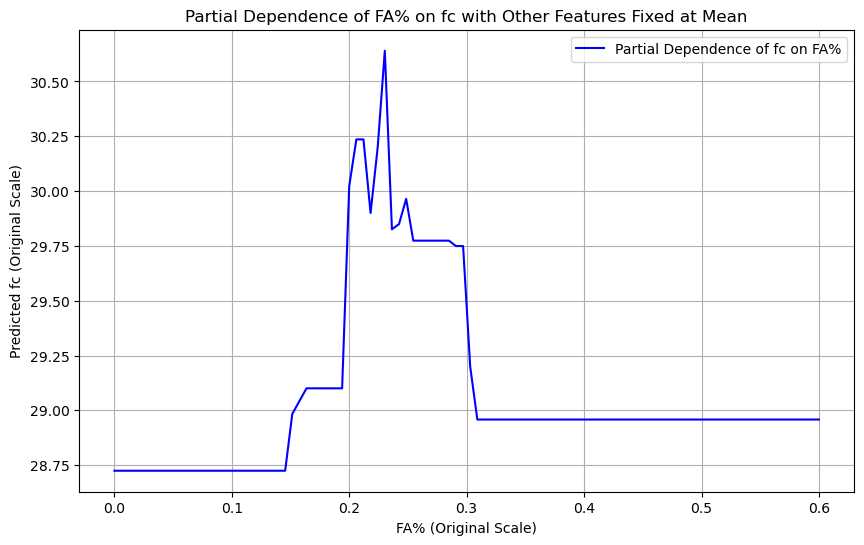

In [31]:

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(fa_percent_original, pdp_predictions_original, label='Partial Dependence of fc on FA%', color='blue')
plt.title('Partial Dependence of FA% on fc with Other Features Fixed at Mean')
plt.xlabel('FA% (Original Scale)')
plt.ylabel('Predicted fc (Original Scale)')
# plt.axhline(0, color='red', linestyle='--', label='Zero Line')  # Add a zero line for reference
plt.legend()
plt.grid()
plt.show()

In [32]:
from sklearn.svm import SVR
params = {
    'kernel': 'rbf',
    'gamma': 'auto',
    'epsilon': 0.2,
    'degree': 3,
    'C': 1
}

# Train the SVR model
svr_model = SVR(**params)
svr_model.fit(Xtrain, ytrain)

# Create a new DataFrame for the partial dependence plot
mean_values = X_normal.mean(axis=0)
fa_percent_range = np.linspace(X_normal[:, features.index('FA%')].min(), X_normal[:, features.index('FA%')].max(), 100)

# Prepare data for predictions
pdp_data = pd.DataFrame(np.tile(mean_values, (fa_percent_range.size, 1)), columns=features)
pdp_data['FA%'] = fa_percent_range  # Vary FA%

# Convert pdp_data to tensor
pdp_data_tensor = torch.FloatTensor(pdp_data.values).to(device)

# Make predictions using the ANN model
# pdp_predictions_normalized = svr_model(pdp_data_tensor).detach().cpu().numpy()  # Use forward pass and detach
pdp_predictions = svr_model.predict(pdp_data)

# Inverse transformation of predictions to original scale
pdp_predictions_original = pdp_predictions.flatten() * y_std + y_mean  # Ensure predictions are 1D

# Inverse transformation of FA% to original scale
fa_percent_original = pdp_data['FA%'] * x_std[features.index('FA%')] + x_mean[features.index('FA%')]
fa_percent_original = fa_percent_original.values.flatten()  # Ensure it's 1D

# Save predictions to a DataFrame
pdp_results = pd.DataFrame({'FA% (Original Scale)': fa_percent_original, 'Predicted_fc': pdp_predictions_original})

# Save the predictions to a CSV file
pdp_results.to_csv('pdp_SVR_7.csv', index=False)


X has feature names, but SVR was fitted without feature names


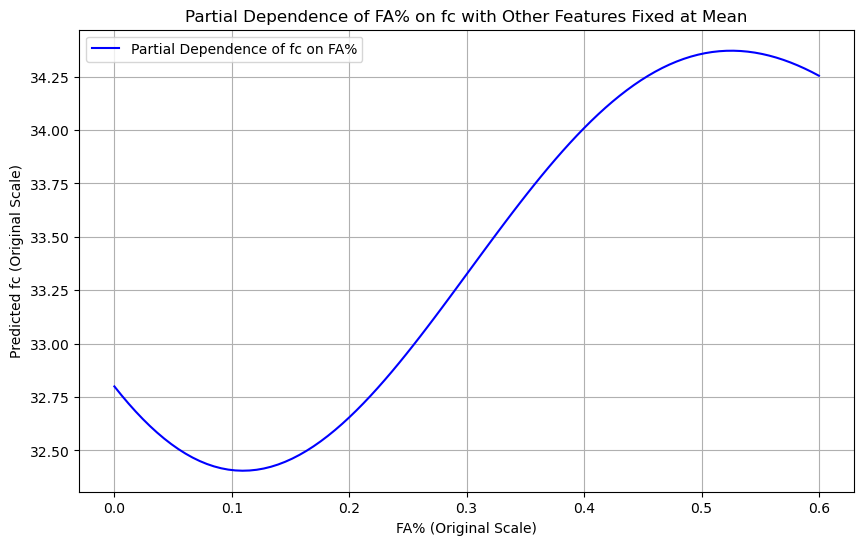

In [33]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(fa_percent_original, pdp_predictions_original, label='Partial Dependence of fc on FA%', color='blue')
plt.title('Partial Dependence of FA% on fc with Other Features Fixed at Mean')
plt.xlabel('FA% (Original Scale)')
plt.ylabel('Predicted fc (Original Scale)')
# plt.axhline(0, color='red', linestyle='--', label='Zero Line')  # Add a zero line for reference
plt.legend()
plt.grid()

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Load and preprocess the data
df = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='7')
df.dropna(inplace=True)

# Define features
features = ['PC', 'PC_TYPE', 'FA', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
            'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%']

X = df[features].values
Y = df['residual'].values  # Ensure this column exists in your DataFrame

# Normalize the data
x_mean = X.mean(0)
x_std = X.std(0)
X_normal = (X - x_mean) / x_std

y_mean = Y.mean()
y_std = Y.std()
Y_normal = (Y - y_mean) / y_std

Xtrain, Xtest, ytrain, ytest = train_test_split(X_normal, Y_normal, train_size=0.85, random_state=42)


In [38]:
# Set Random Forest hyperparameters
n_estimators = 500  # Number of trees
max_depth = 20  # Maximum depth of the trees

# Create the Random Forest model
random_forest_model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=42, bootstrap=True)

# Train the model using the residual values as the target
random_forest_model.fit(Xtrain, ytrain)

# Create a new DataFrame for the partial dependence plot
mean_values = X_normal.mean(axis=0)
fa_percent_range = np.linspace(X_normal[:, features.index('FA%')].min(), X_normal[:, features.index('FA%')].max(), 100)

# Prepare data for predictions
pdp_data = pd.DataFrame(np.tile(mean_values, (fa_percent_range.size, 1)), columns=features)
pdp_data['FA%'] = fa_percent_range  # Vary FA%

# Make predictions
pdp_predictions_normalized = random_forest_model.predict(pdp_data)

# Inverse transformation of predictions to original scale
pdp_predictions_original = pdp_predictions_normalized * y_std + y_mean

# Inverse transformation of FA% to original scale
fa_percent_original = pdp_data['FA%'] * (x_std[features.index('FA%')] if features.index('FA%') < len(x_std) else 1) + (x_mean[features.index('FA%')] if features.index('FA%') < len(x_mean) else 0)

# Save predictions to a DataFrame
pdp_results = pd.DataFrame({'FA% (Original Scale)': fa_percent_original, 'Predicted_fc': pdp_predictions_original})

# Save the predictions to a CSV file
pdp_results.to_csv('pdp_SKIRM_7.csv', index=False)



X has feature names, but RandomForestRegressor was fitted without feature names


ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

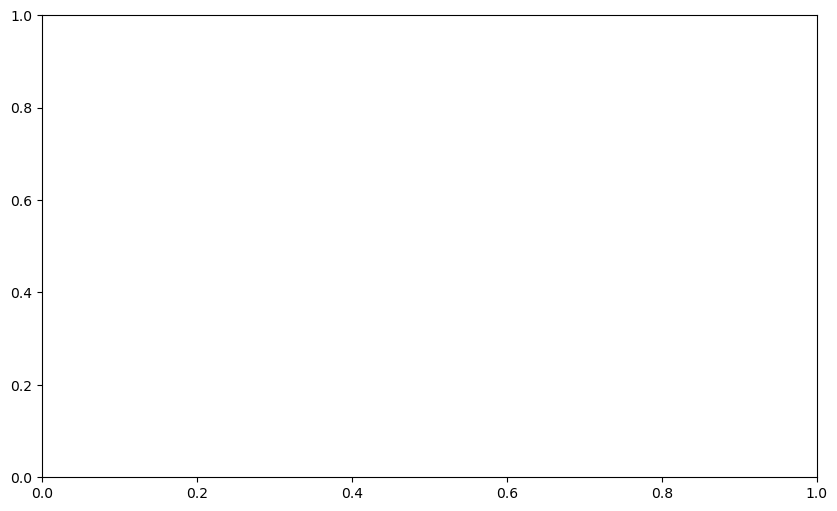

In [36]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(fa_percent_original, pdp_predictions_original, label='Partial Dependence of fc on FA%', color='blue')
plt.title('Partial Dependence of FA% on fc with Other Features Fixed at Mean')
plt.xlabel('FA% (Original Scale)')
plt.ylabel('Predicted fc (Original Scale)')
# plt.axhline(0, color='red', linestyle='--', label='Zero Line')  # Add a zero line for reference
plt.legend()
plt.grid()
plt.show()

## lineplot

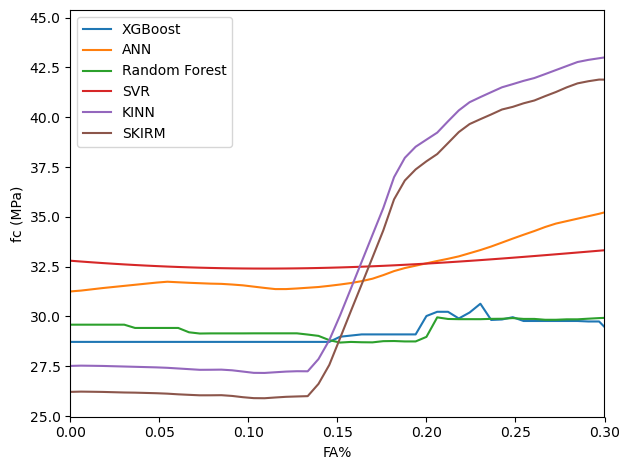

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the PDP results from the CSV file
pdp_results = pd.read_csv('pdp_results_7.csv')  # Change the path if necessary
# print(pdp_results.head())  # View the first few rows
# print(pdp_results.columns)  # Check column names
# print(pdp_results.dtypes)  # Check data types of each column

# Define colors similar to seaborn's vlag palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']  # Blue, Orange, Green, Red, Purple, Brown

# Set the figure size
# plt.figure(figsize=(12, 8))

# Plot each model's predictions with specified colors using .values
plt.plot(pdp_results['FA% (Original Scale)'].values, pdp_results['XGBoost'].values, label='XGBoost', color=colors[0])
plt.plot(pdp_results['FA% (Original Scale)'].values, pdp_results['ANN'].values, label='ANN', color=colors[1])
plt.plot(pdp_results['FA% (Original Scale)'].values, pdp_results['RF'].values, label='Random Forest', color=colors[2])
plt.plot(pdp_results['FA% (Original Scale)'].values, pdp_results['SVR'].values, label='SVR', color=colors[3])
plt.plot(pdp_results['FA% (Original Scale)'].values, pdp_results['KINN'].values, label='KINN', color=colors[4])
plt.plot(pdp_results['FA% (Original Scale)'].values, pdp_results['SKIRM'].values, label='SKIRM', color=colors[5])

# Adding titles and labels
plt.xlabel('FA%')
plt.ylabel('fc (MPa)')
plt.xlim(0, 0.3)  # Set x-axis limits
plt.legend()
# plt.grid()
plt.tight_layout()

# Save the figure with better resolution and spacing
plt.savefig('PDP_7.png', dpi=300)
# plt.show()


Index(['fc (MPa)', 'AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG',
       'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 'LATEX', 'SLUMP', 'VOID',
       'TOTAL_BINDER', 'w/b', 'b/a', 'SCM%', 'CAGG%', 'FAGG%', 'FA%', 'SS%',
       'SF%', 'fc_hat (MPa)', 'residual'],
      dtype='object')


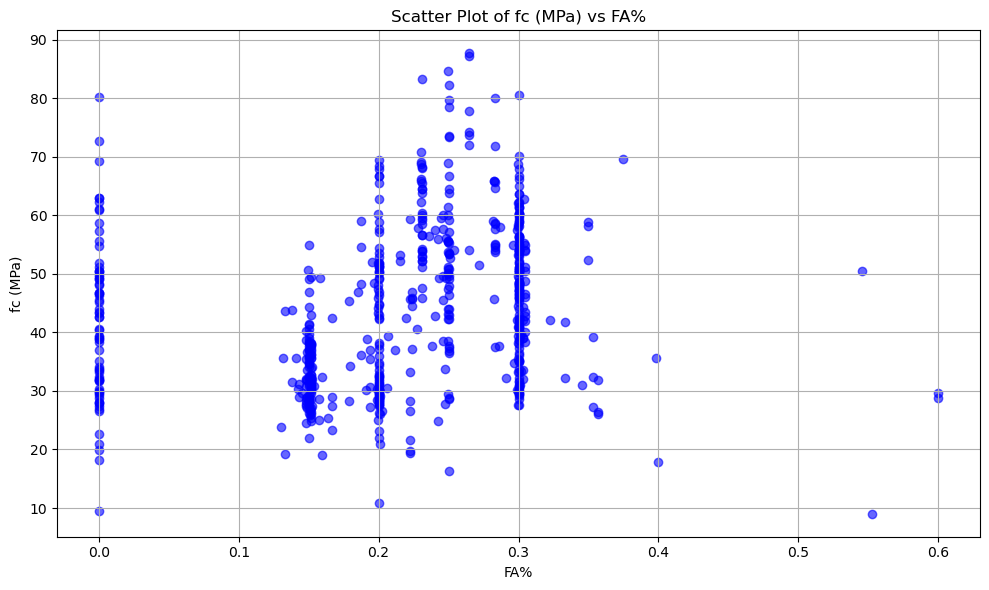

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data from the CSV file
# df = pd.read_csv('your_file.csv')  # Replace 'your_file.csv' with your actual file path
df = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='56')

# Check the columns to ensure they exist
print(df.columns)

# Extract the relevant columns
fa_percent = df['FA%']
fc_mpa = df['fc (MPa)']

# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(fa_percent, fc_mpa, color='blue', alpha=0.6)
plt.title('Scatter Plot of fc (MPa) vs FA%')
plt.xlabel('FA%')
plt.ylabel('fc (MPa)')
plt.grid()

# Show the plot
plt.tight_layout()
plt.show()
